# Implementation of graph portraits on MERFISH dataset comparing GT and preds by LUNA

## imports

In [1]:
import numpy as np
import pandas as pd
import anndata as ad
from scipy.sparse import csr_matrix
import scanpy as sc
import matplotlib.pyplot as plt
import squidpy
import graphcompass as gc
import scipy as sp

CSV_gt_pos = "/home/asalmona/Documents/Ricci/code/LUNA_perturb/Spatial-Transcriptomics-and-Perturbations-Modeling/data_splits/mouse2_slice300_0/metadata_true.csv"
CSV_pred_pos = '/home/asalmona/Documents/Ricci/code/LUNA_perturb/Spatial-Transcriptomics-and-Perturbations-Modeling/data_splits/mouse2_slice300_0/metadata_pred.csv'
all_test_csv_infos = "/home/asalmona/Documents/Ricci/data/MERFISH_LUNA_small_cortex/MERFISH_mouse_cortex_test.csv"
CELL_SECTION = "mouse2_slice300"
sample_id = "mouse2_sample5"
N_GENE_COLS = 254

/home/asalmona/miniconda3/envs/spatial/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# For the 2 position CSVs, use the third CSV to add gene expression columns row by row:
pd_pred = pd.read_csv(CSV_pred_pos)
pd_true = pd.read_csv(CSV_gt_pos)
pd_gene = pd.read_csv(all_test_csv_infos)

# Identify the first N gene columns (assuming these are the gene expression columns)
gene_columns = pd_gene.columns[1:254]

def add_gene_values_by_cell_id_rowwise(df, pd_gene, gene_columns):
    """
    Adds gene expression columns from pd_gene to df by matching on cell_id column, row by row.
    Only the rows present in df will be assigned gene values from pd_gene.
    Keeps original gene column names (not gene_i).
    """
    if 'cell_id' not in df.columns or 'cell_id' not in pd_gene.columns:
        raise KeyError("Both df and pd_gene must have a 'cell_id' column.")

    df = df.copy()
    pd_gene = pd_gene.copy()
    df['cell_id'] = df['cell_id'].astype(str)
    pd_gene['cell_id'] = pd_gene['cell_id'].astype(str)
    pd_gene.set_index('cell_id', inplace=True)

    # Build output DataFrame
    gene_values = []
    for idx, row in df.iterrows():
        cid = row['cell_id']
        if cid in pd_gene.index:
            gene_values.append(pd_gene.loc[cid, list(gene_columns)].values)
        else:
            # If not found, fill with NaN
            gene_values.append([np.nan] * len(gene_columns))

    # Use the actual gene column names from pd_gene/gene_columns for the output DataFrame
    gene_array = np.stack(gene_values)
    gene_col_names = list(gene_columns)
    gene_df = pd.DataFrame(gene_array, columns=gene_col_names, index=df.index)

    merged = pd.concat([df.reset_index(drop=True), gene_df.reset_index(drop=True)], axis=1)
    return merged

pd_pred_copy = add_gene_values_by_cell_id_rowwise(pd_pred, pd_gene, gene_columns)
pd_true_copy = add_gene_values_by_cell_id_rowwise(pd_true, pd_gene, gene_columns)

In [3]:
# save for check
pd_pred_copy.to_csv("pd_pred_copy_with_genes.csv", index=False)
pd_true_copy.to_csv("pd_true_copy_with_genes.csv", index=False)


## anndata object

In [4]:
from to_adata import build_fused_adata

adata_fused = build_fused_adata(
    pred_csv="pd_pred_copy_with_genes.csv",
    true_csv="pd_true_copy_with_genes.csv",
)


In [5]:
"1810046K07Rik" in adata_fused.var_names

True

/tmp/ipykernel_143755/2226809176.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/home/asalmona/miniconda3/envs/spatial/lib/python3.10/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'cell_class' as categorical
/home/asalmona/miniconda3/envs/spatial/lib/python3.10/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'library' as categorical


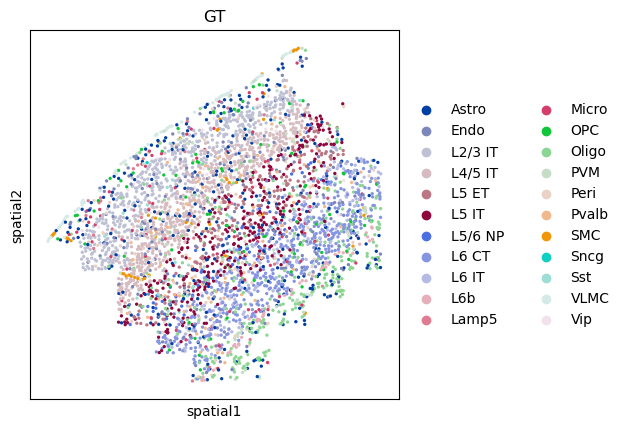

/tmp/ipykernel_143755/2226809176.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/home/asalmona/miniconda3/envs/spatial/lib/python3.10/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'cell_class' as categorical
/home/asalmona/miniconda3/envs/spatial/lib/python3.10/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'library' as categorical


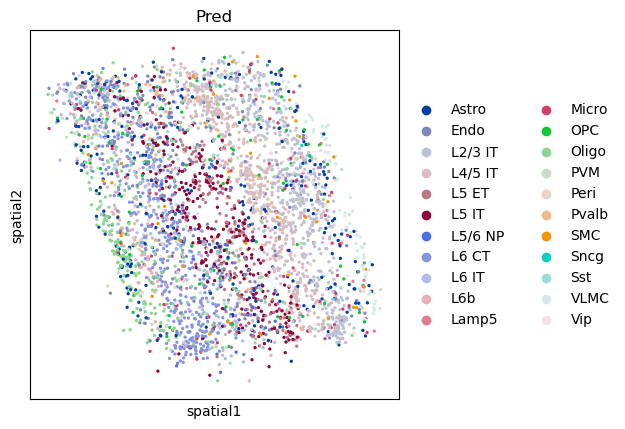

In [6]:
# plot both with scanpy to ensure the format 
sc.pl.spatial(
    adata_fused[adata_fused.obs['library'] == "gt"], 
    color="cell_class", 
    title="GT", 
    spot_size=0.01
)
sc.pl.spatial(
    adata_fused[adata_fused.obs['library'] == "pred"], 
    color="cell_class", 
    title="Pred", 
    spot_size=0.01
)

/tmp/ipykernel_143755/3108761246.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/home/asalmona/miniconda3/envs/spatial/lib/python3.10/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'cell_class' as categorical
/home/asalmona/miniconda3/envs/spatial/lib/python3.10/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'library' as categorical


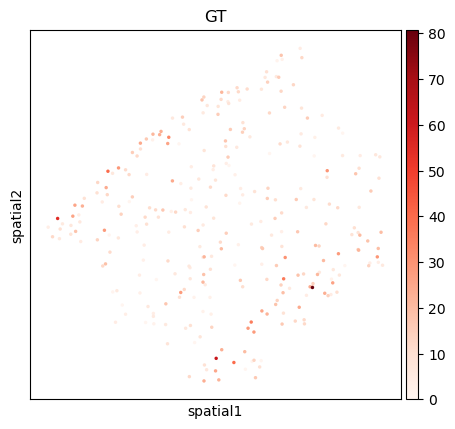

/tmp/ipykernel_143755/3108761246.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/home/asalmona/miniconda3/envs/spatial/lib/python3.10/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'cell_class' as categorical
/home/asalmona/miniconda3/envs/spatial/lib/python3.10/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'library' as categorical


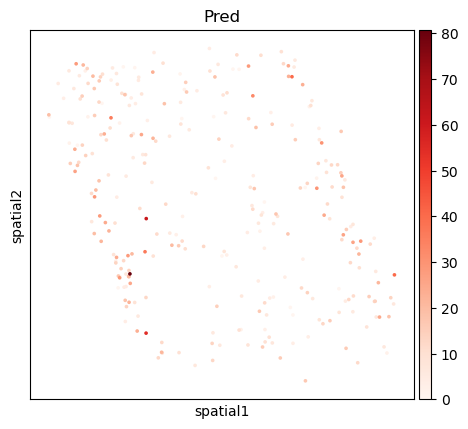

In [15]:
# plotting only cell type astro and gene expression 
astro_pred = adata_fused[adata_fused.obs['cell_class'] == "Astro"]
astro_gt = adata_fused[adata_fused.obs['cell_class'] == "Astro"]
sc.pl.spatial(
    astro_gt[astro_gt.obs['library'] == "gt"], 
    color="Aqp4", 
    title="GT", 
    spot_size=0.01,
    cmap="Reds"
)
sc.pl.spatial(
    astro_pred[astro_pred.obs['library'] == "pred"], 
    color="Aqp4", 
    title="Pred", 
    spot_size=0.01,
    cmap="Reds"
)


0.06730987763344719
0.2136131001089814


(<Figure size 1735x1020 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x7bb9de0480d0>)

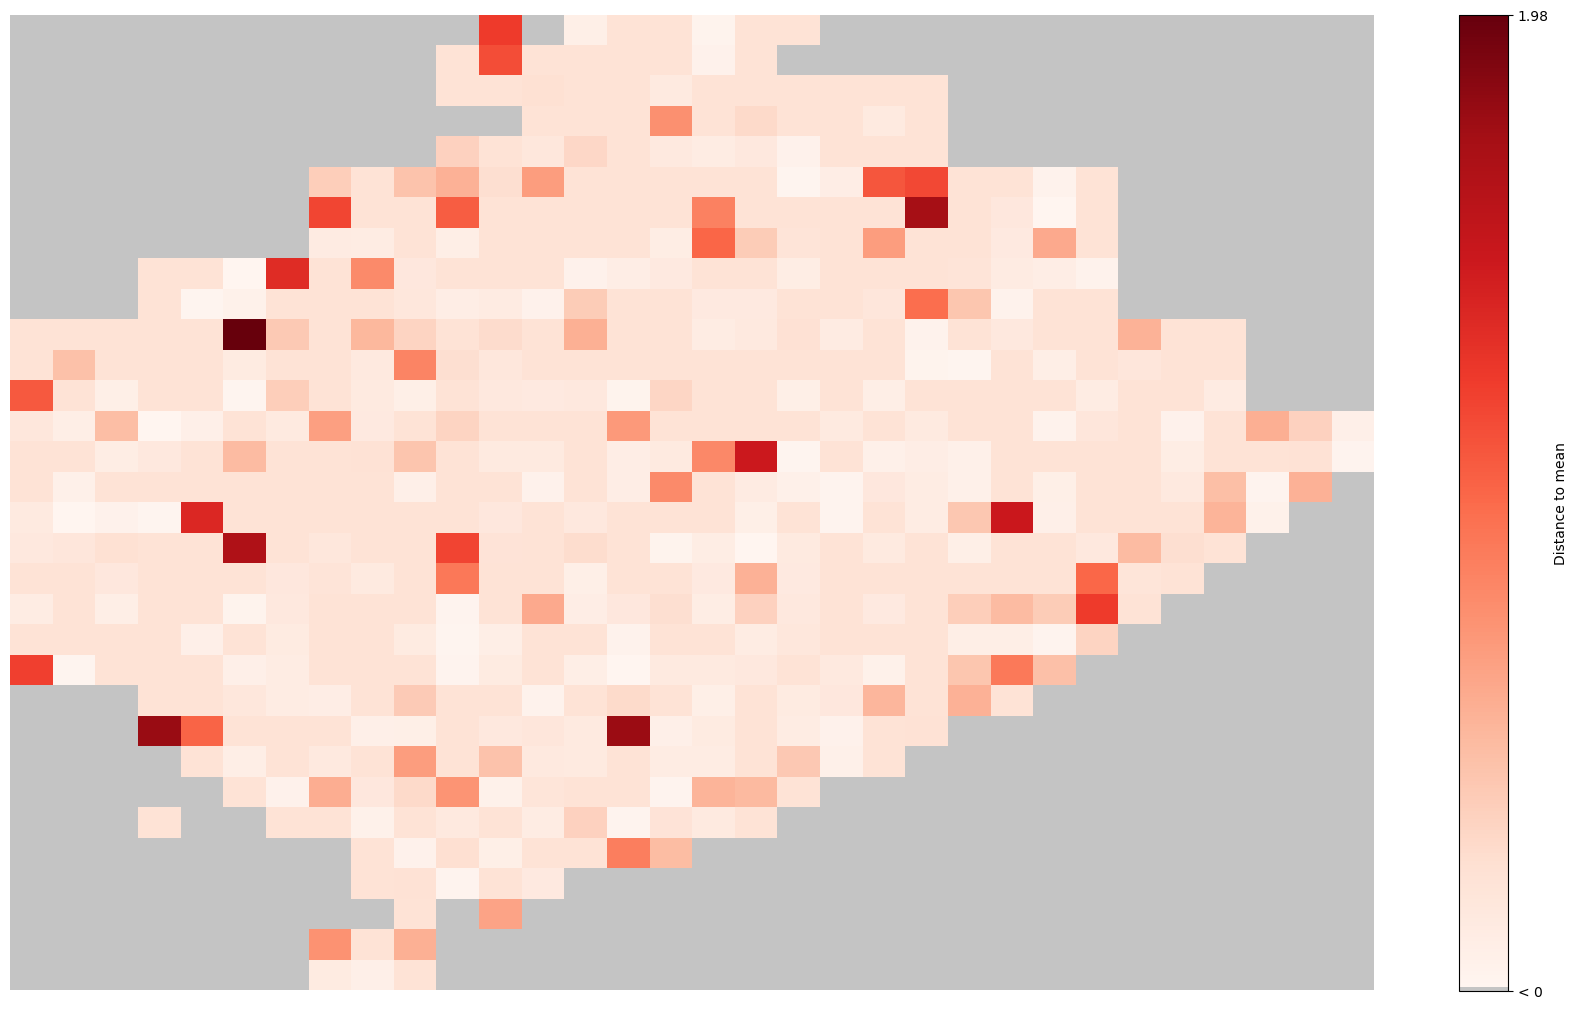

In [22]:
from spatial_correlation import spatial_gene_distance_grid

# Calculate the spatial correlation of the gene expression in ST data

test_dist = spatial_gene_distance_grid(adata_fused[adata_fused.obs['library'] == "gt"], "Frem2", 32)
print(test_dist.variance)
print(test_dist.global_mean)
test_dist.plot_distance(cmap="Reds")

In [23]:
gene_names = adata_fused.var_names.tolist()
from spatial_correlation import spatial_gene_distance_grid

top_genes_dict = {'000': 0}
minmax_gene, minmax_gene_var = '000', 0

for gene in gene_names:
    dist = spatial_gene_distance_grid(adata_fused[adata_fused.obs['library'] == "gt"], gene, 16)
    var = dist.variance
    if len(top_genes_dict) < 12:
        top_genes_dict[gene] = var
        if var < minmax_gene_var:
            minmax_gene, minmax_gene_var = gene, var
    else:
        if var > minmax_gene_var:
            top_genes_dict.pop(minmax_gene)
            top_genes_dict[gene] = var
            # gets the new minmax gene from the top 10
            minmax_gene = min(top_genes_dict, key=top_genes_dict.get)
            minmax_gene_var = top_genes_dict[minmax_gene]

top_genes = list(top_genes_dict.keys())

In [24]:
print(top_genes)

['C1ql3', 'Cux2', 'Gfap', 'Igfbp5', 'Ptprt', 'Rorb', 'Slc30a3', 'Sox10', 'Sulf2', 'Unc5b', 'Vtn', 'Wipf3']


C1ql3 with variance 7.4486259964893495
Cux2 with variance 9.193474686834278
Gfap with variance 18.493619493083873
Igfbp5 with variance 14.190839679051885
Ptprt with variance 8.439496379117694
Rorb with variance 7.061482616202185
Slc30a3 with variance 9.8553957436145
Sox10 with variance 7.837383904532295
Sulf2 with variance 12.859950385387265
Unc5b with variance 6.047797943916847
Vtn with variance 10.473080805123244
Wipf3 with variance 7.901654724198615


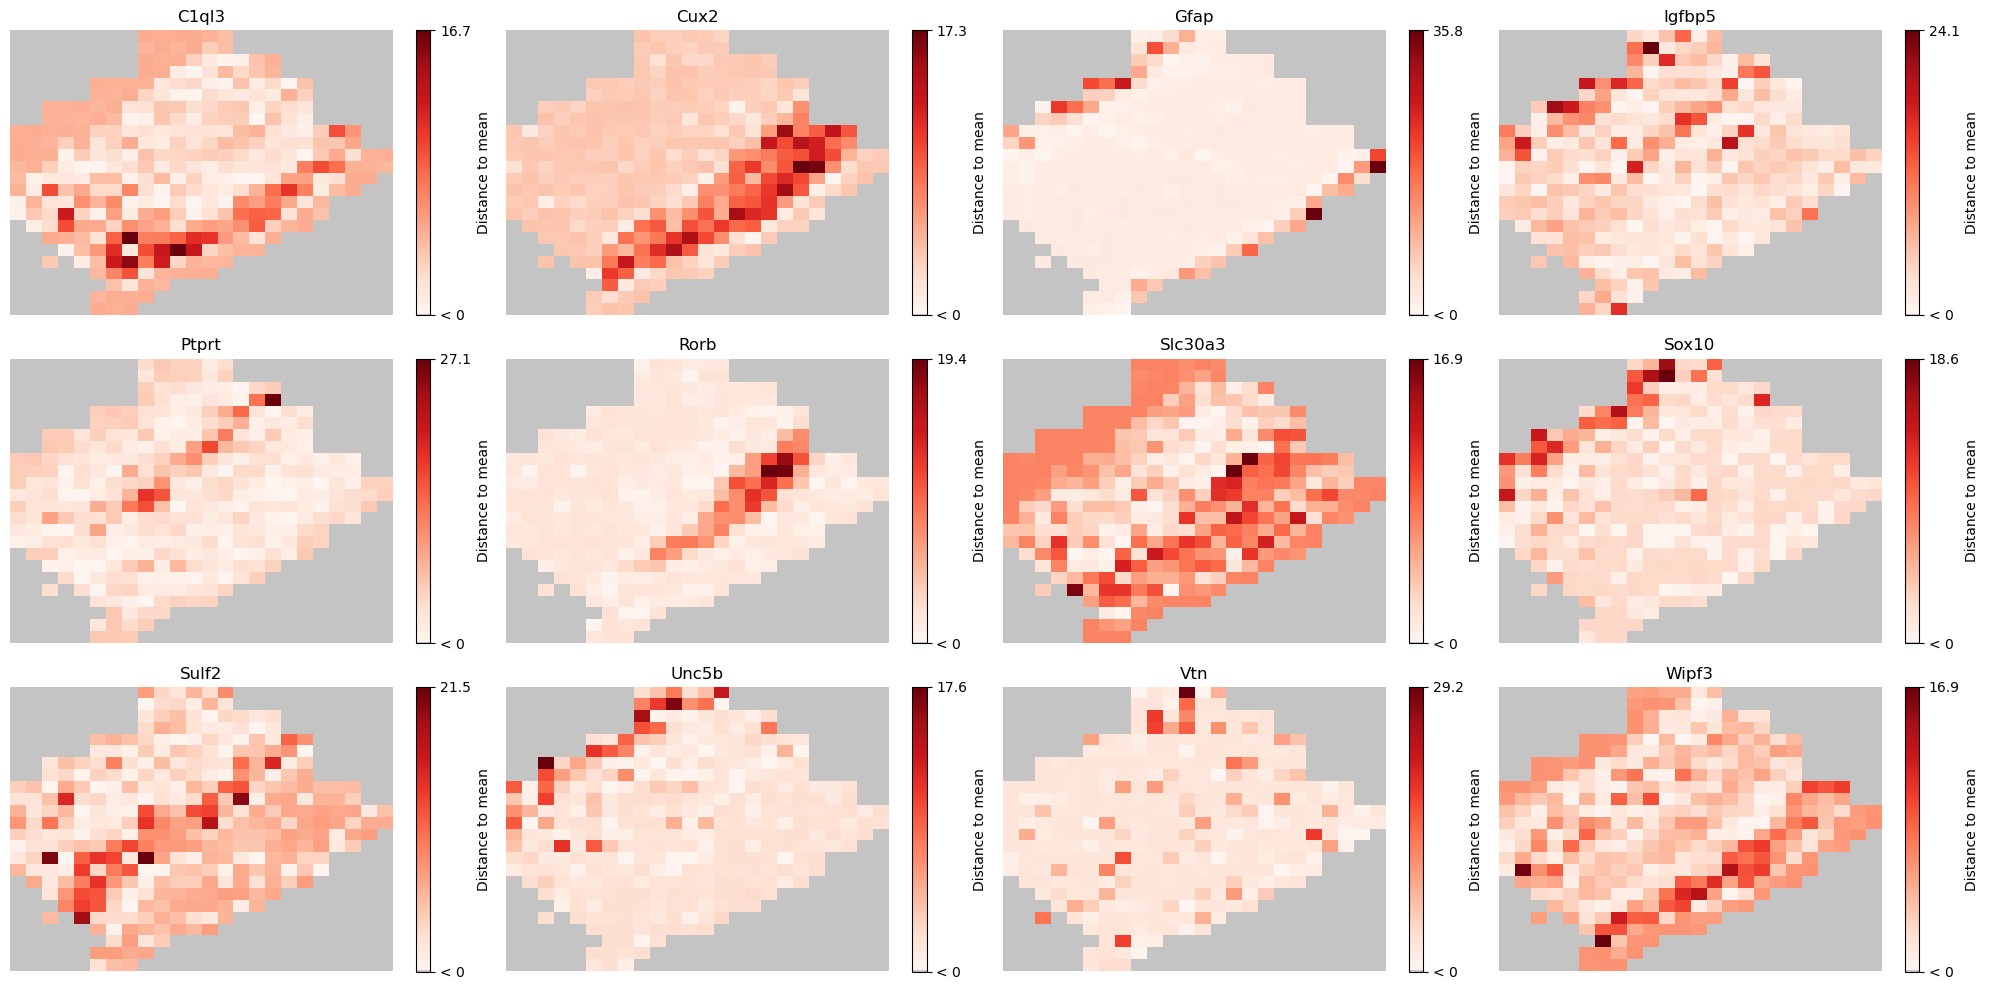

In [25]:
list_of_grids = []
for gene in top_genes:
    dist = spatial_gene_distance_grid(adata_fused[adata_fused.obs['library'] == "gt"], gene, 24)
    list_of_grids.append(dist)

# Plot all grids in a single figure
fig, axes = plt.subplots(3, 4, figsize=(20, 10))
axes = axes.ravel()

for i, dist in enumerate(list_of_grids):

    dist.plot_distance(ax=axes[i], cmap="Reds")
    axes[i].set_title(f"{top_genes[i]}")
    axes[i].axis('off')
    print(f"{top_genes[i]} with variance {dist.variance}")

plt.tight_layout()
plt.show()

## graph compass set up

In [8]:
adata_fused.obs.head()

,cell_id,cell_class,coord_X,coord_Y,library
cell_id,,,,,
133277__gt,133277,Oligo,0.026848,0.116121,gt
91841__gt,91841,Astro,0.052199,0.381970,gt
55540__gt,55540,L6 CT,0.160931,0.067541,gt
55257__gt,55257,L5 IT,0.063948,0.133388,gt
103231__gt,103231,L5 ET,0.023917,0.035204,gt


In [9]:
# define library_key and cluster_key for computing spatial graphs using `squidpy.gr.spatial_neighbors`
cluster_key="cell_class"
library_key="library"
condition_key="library"


In [10]:
# subset data to conditions of interest: normal, non-progressors (ctrl) and progressors (case)
adata_fused = adata_fused[adata_fused.obs[condition_key].isin(["gt", "pred"])]
adata_fused.obs.head()

,cell_id,cell_class,coord_X,coord_Y,library
cell_id,,,,,
133277__gt,133277,Oligo,0.026848,0.116121,gt
91841__gt,91841,Astro,0.052199,0.381970,gt
55540__gt,55540,L6 CT,0.160931,0.067541,gt
55257__gt,55257,L5 IT,0.063948,0.133388,gt
103231__gt,103231,L5 ET,0.023917,0.035204,gt


In [11]:
adata_fused.obs[library_key] = adata_fused.obs[library_key].astype("category")
if condition_key in adata_fused.obs:
    adata_fused.obs[condition_key] = adata_fused.obs[condition_key].astype("category")
adata_fused.obs[cluster_key] = adata_fused.obs[cluster_key].astype("category")
if condition_key in adata_fused.obs:
    adata_fused.obs[cluster_key] = adata_fused.obs[cluster_key].astype("category")
adata_fused.obs.head()

/tmp/ipykernel_131165/1288465521.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_fused.obs[library_key] = adata_fused.obs[library_key].astype("category")


,cell_id,cell_class,coord_X,coord_Y,library
cell_id,,,,,
133277__gt,133277,Oligo,0.026848,0.116121,gt
91841__gt,91841,Astro,0.052199,0.381970,gt
55540__gt,55540,L6 CT,0.160931,0.067541,gt
55257__gt,55257,L5 IT,0.063948,0.133388,gt
103231__gt,103231,L5 ET,0.023917,0.035204,gt


In [12]:
# compute pairwise similarities between cell-type specific graphs across samples
### results are stored in adata.uns["pairwise_similarities"]

gc.tl.distance.compare_conditions(
    adata=adata_fused,
    library_key=library_key,
    cluster_key=cluster_key,
    method="portrait",
    kwargs_spatial_neighbors={
        'coord_type': 'generic',
        'delaunay': True,  
    }  
)

Computing spatial graphs...


100%|██████████| 1000/1000 [00:00<00:00, 3133.66/s]


Computing graph similarities...


100%|██████████| 22/22 [00:39<00:00,  1.79s/it]

Done!


0it [00:00, ?it/s]/home/asalmona/Documents/Ricci/code/LUNA_perturb/graphcompass/src/graphcompass/pl/_distance.py:31: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[sample_a][sample_b] = 0.0
/home/asalmona/Documents/Ricci/code/LUNA_perturb/

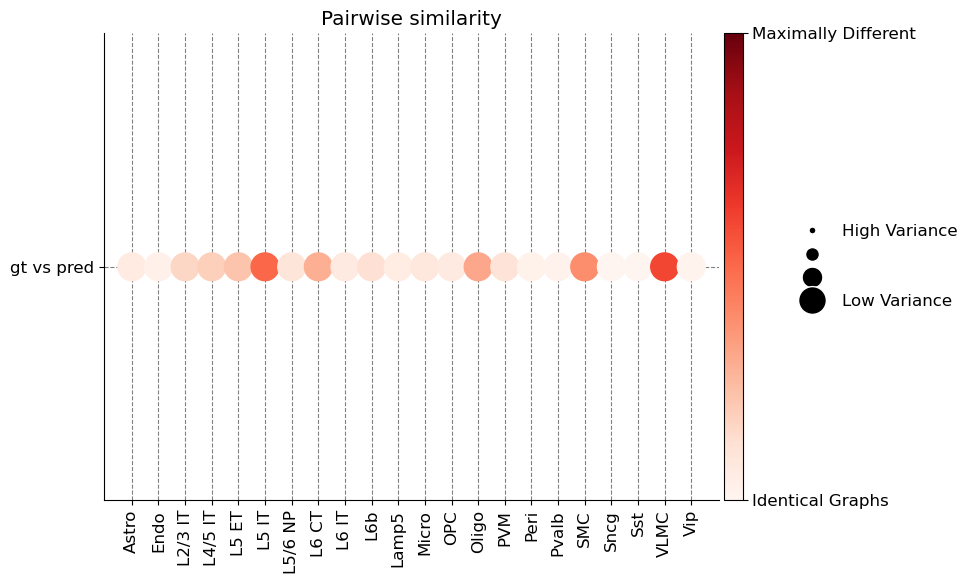

In [13]:
## Note: dot size indicates the variance between samples. The smaller the dot the more variance there is 
## between samples.

gc.pl.distance.compare_conditions(
    adata=adata_fused,
    library_key=library_key,
    condition_key=condition_key,
    control_group="gt",
    # add_ncells_and_density_plots=True,
    palette="Reds",
    dpi=100,
    figsize=(10,6),
#     save="figures/mibitof_portrait.pdf"
)

In [14]:
kwargs_spatial_neighbors = {
    "coord_type": "generic",
    "delaunay": True,
}

gc.tl._filtration_curves.compare_conditions(
    adata_fused,
    library_key=library_key,
    cluster_key=cluster_key,
    condition_key=condition_key,
    attribute="weight",
    compute_spatial_graphs=True,
    kwargs_spatial_neighbors=kwargs_spatial_neighbors,
    copy=False,
)

Computing spatial graphs...


100%|██████████| 1000/1000 [00:00<00:00, 3227.80/s]
/home/asalmona/miniconda3/envs/spatial/lib/python3.10/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Computing edge weights...


100%|██████████| 2/2 [00:00<00:00,  4.82it/s]


Computing edge weight threshold values...
Creating filtration curves...


100%|██████████| 2/2 [00:00<00:00, 199.01it/s]

Done!


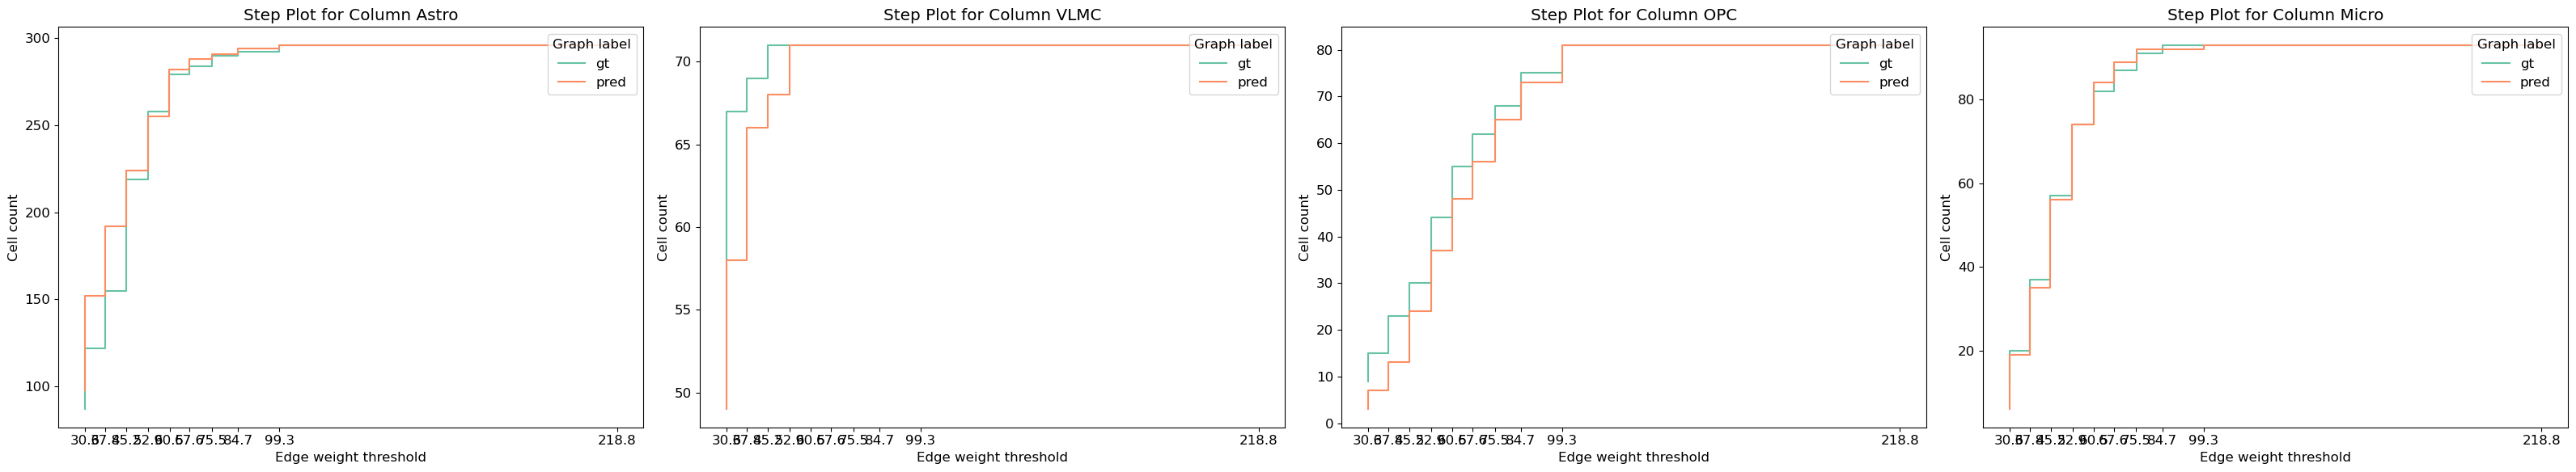

In [19]:
gc.pl._filtration_curves.compare_conditions(
        adata_fused, 
        node_labels=["Astro", "VLMC", "OPC", "Micro"],
)